In [247]:
import networkx as nx
import pickle
import pandas as pd
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import plotly.express as px
import re
from urllib.request import urlopen
import json
import sys
import os

# Set up a helper file and load in the relevant data

In [2]:
# helper functions for pickle-related stuff
# dump_pickle will prevent accidental overwrites
def load_pickle(filename):
    with open(filename, 'rb') as handle:
        b = pickle.load(handle)
    return b
def dump_pickle(filepath, filename, var, warn=True): 
    current_folder = os.getcwd()
    os.chdir(filepath)
    if filename in os.listdir(os.getcwd()) and warn: 
        okay = 'O'
        while okay.lower() not in ['y','n']: 
            okay = input("WARNING: Filename is already present in directory. Overwrite? Y/N: ")
        if okay.lower() == 'n':
            os.chdir(current_folder)
            return
    with open(filepath+filename,'wb') as handle:
        pickle.dump(var, handle)
    return

def dex_as_key(dict_name, index):
    return dict_name[list(dict_name.keys())[index]]

In [3]:
full_info_path = 'C:\\Users\\samue\\Documents\\Metal_Data 2025_FINAL\\First_Update\\band_info\\'
full_info_file = '12-10-2025 Band Info.pkl'

band_member_path = 'C:\\Users\\samue\\Documents\\Metal_Data 2025_FINAL\\First_Update\\band_member_info\\'
band_member_file = '12-10-2025 Band Member Info.pkl'

graph_path = 'C:\\Users\\samue\\Documents\\Metal_Data 2025_FINAL\\First_Update\\graphs\\'
band_graph_file = '12-10-2025_band_graph.pkl'

id_conv_path= 'C:\\Users\\samue\\Documents\\Metal_Data 2025_FINAL\\First_Update\\band_to_member\\'
band_id_to_name_file = '12-10-2025_band_id_to_name.pkl'
name_to_band_id_file = '12-10-2025_name_to_band_id.pkl'

band_to_member_path= 'C:\\Users\\samue\\Documents\\Metal_Data 2025_FINAL\\First_Update\\band_to_member\\'
band_to_member_file = '12-10-2025_band_to_member.pkl'
member_to_band_file = '12-10-2025_member_to_band.pkl'

In [4]:
band_info = load_pickle(full_info_path+full_info_file)
band_member_info = load_pickle(band_member_path+band_member_file)
band_graph = load_pickle(graph_path + band_graph_file)
band_id_to_name = load_pickle(id_conv_path + band_id_to_name_file)
name_to_band_id = load_pickle(id_conv_path + name_to_band_id_file)
band_to_member = load_pickle(band_to_member_path+band_to_member_file)
member_to_band = load_pickle(band_to_member_path + member_to_band_file)

# Helper funtions to generate communities, tally countries, detect genres, and provide basic descriptive stats

In [219]:
def detect_genre(in_id, genre): 
    in_str = band_info[in_id]['described_genre']
    if genre.lower() in in_str.lower(): 
        return 1
    else: 
        return 0
def get_country(in_id, band_info):
    use_info = band_info[str(in_id)]
    if 'origin_county' in use_info.keys(): 
        return use_info['origin_county']
    else: 
        return None

def tally_countries(community): 
    mix_list = [(band_id_to_name[i], band_info[i]['origin_county']) for i in community]
    country_dict = dict()
    for band in mix_list: 
        country = band[1]
        if country in country_dict.keys(): 
            country_dict[country] += 1
        else: 
            country_dict[country] = 1
    return country_dict

def lcc_maker(band_graph, seed):
    lcc = band_graph.subgraph(max(nx.connected_components(band_graph),key = len)).copy()
    communities_generator = nx.community.louvain_communities(lcc,seed = 666)
    communities_generator = sorted(communities_generator, key = lambda x: -len(x))
    return communities_generator

def community_nationlist(community): 
    tallied_countries = tally_countries(community)
    tallied_countries = [(j, tallied_countries[j]) for j in tallied_countries]
    tallied_countries = sorted(tallied_countries, key = lambda x: -x[1])
    total = sum([i[1] for i in tallied_countries])
    countries_and_number = [(i[0],i[1]) for i in tallied_countries]
    if len(tallied_countries) <= 1:
        country_centrality = 1
        top_two_country_centrality = 1
    else: 
        country_centrality = round(tallied_countries[0][1]/total,2)
        top_two_country_centrality = round((tallied_countries[0][1] + tallied_countries[1][1])/total,2)
    outlist = (i, countries_and_number, total, country_centrality, top_two_country_centrality)
    return outlist

In [355]:
def tally_genres(community, band_info, proportion = False):
    genre_list = ['Black','Death','Doom','Electronic','Experimental','Folk','Gothic','Grindcore',
                  'Groove','Heavy','Core','Power','Progressive', 'Speed',
                  'Symphonic','Thrash']
    genre_list = [i.lower() for i in genre_list]
    genre_dict = {genre: 0 for genre in genre_list}
    for band_id in community: 
        genre = band_info[band_id]['described_genre'].lower()
        #print(genre)
        for test_genre in genre_list: 
            if test_genre.lower() in genre: 
                genre_dict[test_genre] += 1
        if 'stoner' in genre and 'doom' not in genre: 
            genre_dict['doom'] += 1
        if 'sludge' in genre and 'doom' not in genre:
            genre_dict['doom'] += 1
        if 'industrial' in genre and 'electronic' not in genre: 
            genre_dict['electronic'] += 1
        if 'avant-garde' in genre and 'experimental' not in genre: 
            genre_dict['experimental'] += 1
        if 'viking' in genre and 'folk' not in genre:
            genre_dict['folk'] += 1
        if 'pagan' in genre and 'folk' not in genre: 
            genre_dict['folk'] += 1
        if 'metalcore' in genre: 
            genre_dict['core'] += 1
        if 'deathcore' in genre:
            genre_dict['core'] += 1
    if proportion: 
        total_genre = len(community)
    else: 
        total_genre = 1
    genre_dict = {i: round(genre_dict[i]/total_genre,2) for i in genre_dict.keys()}
    return genre_dict
    
def tally_region(community, band_info, proportion = False): 
    region_dict = dict()
    for band_id in community:
        try:
            region = band_info[band_id]['location']
            region = region.split(',')[1].strip()
            if region in region_dict.keys(): 
                region_dict[region] += 1
            else: 
                region_dict[region] = 1
        except: 
            pass
    return region_dict

def get_community_subgraphs(communities_generator, band_graph): 
    outlist = []
    for generated_community in communities_generator: 
        community_subgraph = band_graph.subgraph(generated_community)
        outlist.append(community_subgraph)
    return outlist

def get_degree_info(community):
    degree_list = [i for i in community.degree()]
    max_degree = max(degree_list, key = lambda x: x[1])
    max_degree = (max_degree[0], band_id_to_name[max_degree[0]], max_degree[1])
    average_degree = round(sum([i[1] for i in degree_list])/len(degree_list),2)
    endbranch_count = sum([1 if i[1] == 1 else 0 for i in degree_list])
    return {'max_degree': max_degree,'average_degree': average_degree, 
            'endbranch_count': endbranch_count,'degree_list': degree_list}

def name_the_community(nationlist): 
    if nationlist[3] >= 0.7: 
        outlist= nationlist[1][0][0]
    elif nationlist[4] >= 0.7: 
        outlist = f"{nationlist[1][0][0]} and {nationlist[1][1][0]}"
    else: 
        outlist = "Multinational"
    return outlist

def choropleth(international_classics):
    international_classics = tally_countries(international_classics)
    international_classics = [(i, international_classics[i]) for i in international_classics.keys()]
    international_classics = sorted(international_classics, key = lambda x: -x[1])
    
    df = pd.DataFrame(international_classics, columns = ['Country','Count'])
    df['logcount'] = np.log(df['Count'])
    
    return px.choropleth(data_frame=df,locations='Country',locationmode='country names',color='Count',
             projection='kavrayskiy7', width = 1000, height=500)

def get_centralities(subgraph): 
    eigcent = nx.eigenvector_centrality_numpy(subgraph)
    degcent = nx.degree_centrality(subgraph)
    eigcent = [(band_id_to_name[i], eigcent[i]) for i in eigcent.keys()]
    degcent = [(band_id_to_name[i], degcent[i]) for i in degcent.keys()]
    return {'eigcent': eigcent, 'degcent': degcent}

def get_remaining_descriptions(community_graph): 
    return {"density":nx.density(community_graph), 
            "clustering": nx.average_clustering(community_graph),
            "assortativity": nx.degree_assortativity_coefficient(community_graph)}

# Assemble the info for communities

In [348]:
subgraphs = get_community_subgraphs(communities_generator,band_graph)

outdict = dict()

for i in range(len(subgraphs)): 
    subgraph = subgraphs[i]
    community = communities_generator[i]
    nationlist = community_nationlist(community)
    name = name_the_community(nationlist)
    genres = tally_genres(community, band_info, proportion = False)
    degree_info = get_degree_info(subgraph)
    centralities = get_centralities(subgraph)
    remaining_descriptions = get_remaining_descriptions(subgraph)

    outdict[i] = {'subgraph': subgraph, 'community': community,
                 'nationlist': nationlist, 'name':name,
                 'genres': genres, 'degree_info': degree_info,
                 'centralities': centralities, 
                  'remaining_descriptions': remaining_descriptions}
    

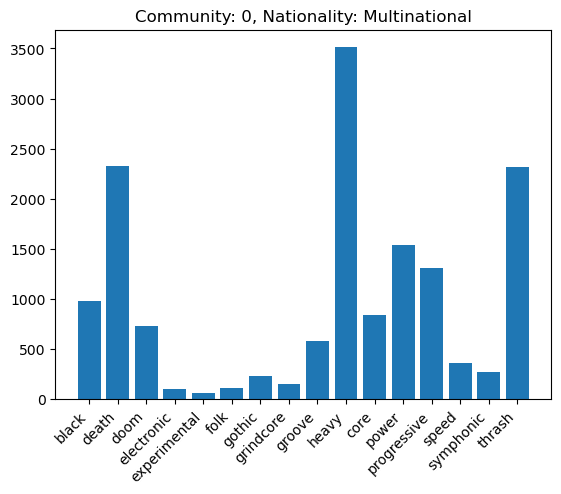

In [350]:
def plot_genres(outdict, selected):
    name = outdict[selected]['name']
    genres = outdict[selected]['genres']
    genres_x = [i for i in genres.keys()]
    genres_y = [genres[i] for i in genres.keys()]
    plt.bar(genres_x, genres_y)
    plt.xticks(rotation=45, ha='right')
    plt.title(f"Community: {selected}, Nationality: {name}")

plot_genres(outdict, 0)


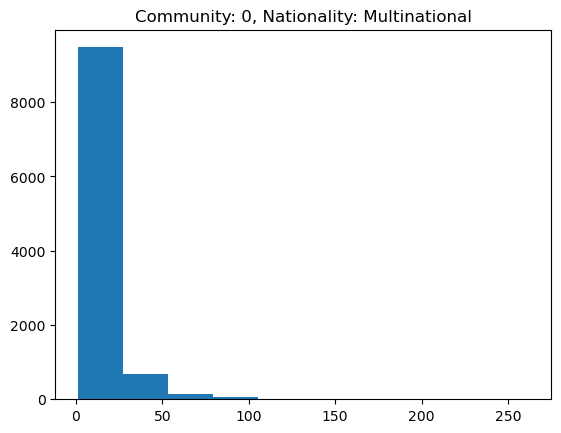

In [351]:
def hist_degrees(outdict, selected):
    name = outdict[selected]['name']
    degree_list = [i[1] for i in outdict[selected]['degree_info']['degree_list']]
    plt.hist(degree_list)
    plt.title(f"Community: {selected}, Nationality: {name}")

hist_degrees(outdict,0)

(array([61.,  8., 12.,  9.,  7.,  7.,  3.,  3.,  0.,  4.]),
 array([7.83402529e-04, 1.00705062e-01, 2.00626722e-01, 3.00548382e-01,
        4.00470042e-01, 5.00391701e-01, 6.00313361e-01, 7.00235021e-01,
        8.00156681e-01, 9.00078340e-01, 1.00000000e+00]),
 <BarContainer object of 10 artists>)

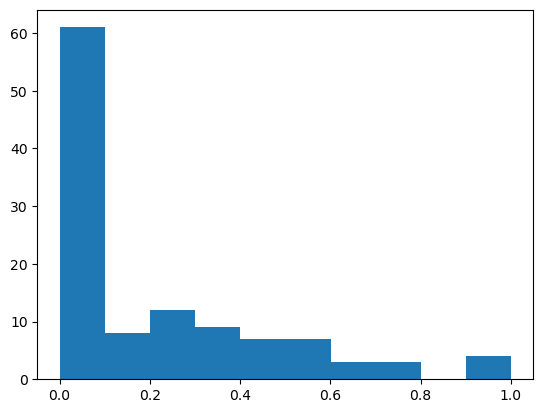

In [352]:
assorts = [outdict[i]['remaining_descriptions']['density'] for i in outdict.keys()]
plt.hist(assorts)

In [353]:
outdict[i]['centralities']['eigcent']

[(('3540560214',
   'https://www.metal-archives.com/bands/Teaser_Sweet/3540560214',
   ['Teaser Sweet', 'Sweden', 'Heavy Metal/Hard Rock', 'Active']),
  0.5),
 (('3540356965',
   'https://www.metal-archives.com/bands/Below/3540356965',
   ['Below', 'Sweden', 'Heavy Metal', 'Changed name']),
  0.5),
 (('3540356966',
   'https://www.metal-archives.com/bands/Firebug/3540356966',
   ['Firebug', 'Sweden', 'Heavy Metal', 'Changed name']),
  0.5000000000000001),
 (('17739',
   'https://www.metal-archives.com/bands/Hellfueled/17739',
   ['Hellfueled', 'Sweden', 'Heavy Metal', 'Active']),
  0.5)]

# Let's get some descriptive stats.

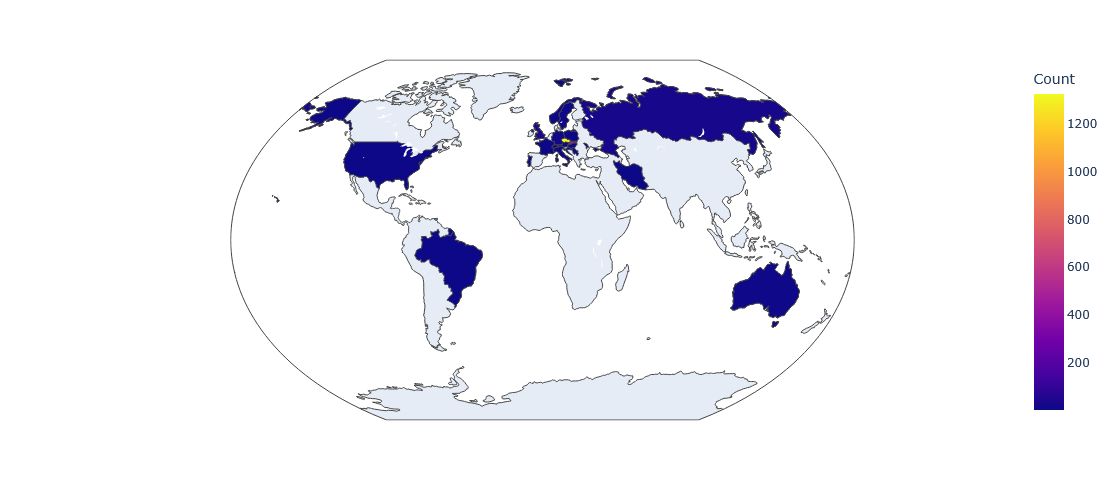

In [362]:
choropleth(outdict[23]['community'])

# Now let's test out choropleth stuff

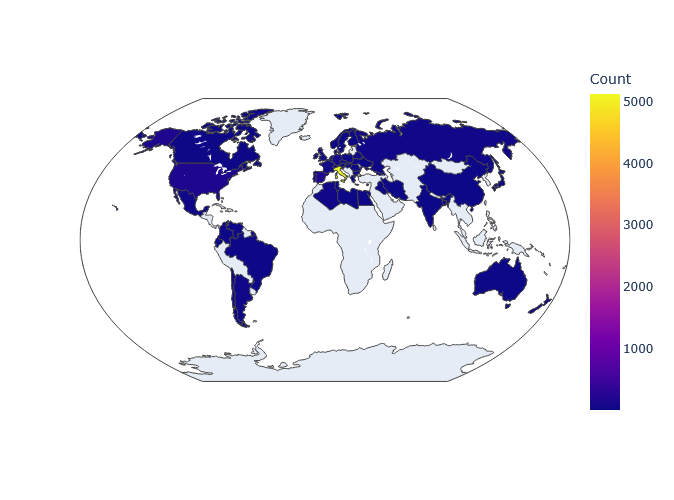

In [135]:
chloropleth(communities_generator, 3)

In [17]:
sorted([[1,5,4],[2,3],[1]], key=lambda x: -1*len(x))

[[1, 5, 4], [2, 3], [1]]

In [19]:
test = [i for i in communities_generator[7] if band_info[i]['origin_county'] == 'Finland']
test = lcc.subgraph(test)
nu_test_groups = nx.community.louvain_communities(test, seed=666)
nu_test_groups= sorted(nu_test_groups, key = lambda x: -1*len(x))
test = nu_test_groups[4]
tallied_region = tally_region(test, band_info)
#tallied_region = {i: tallied_region[i] for i in tallied_region.keys() if '/' not in i and '(early)' not in i and ';' not in i
                 #and '(later)' not in i and 'Laajavuorenkuja' not in i and tallied_region[i] != 1}
tallied_region = {i: tallied_region[i] for i in tallied_region.keys() if tallied_region[i] >= 10}

edited_finnish_regions = {
    'Pohjois-Pohjanmaa': "Northern Ostrobothnia",
    'Pohjois-Karjala': "North Karelia",
    'Uusimaa': 'Uusimaa',
    'Kymenlaakso': 'Kymenlaakso',
    'Varsinais-Suomi': "Finland Proper",
    'Etelä-Pohjanmaa': "Southern Ostrobothnia",
    'Keski-Suomi': "Central Finland",
    'Pirkanmaa': "Pirkanmaa",
    'Lappi': "Lapland",
    'Päijät-Häme': "Päijät-Häme",
    'Kainuu': 'Kainuu',
    'Kanta-Häme': "Tavastia Proper",
    'Satakunta': 'Satakunta',
    'Etelä-Savo': "Southern Savonia",
    'Pohjanmaa': "Ostrobothnia",
    'Keski-Pohjanmaa': "Central Ostrobothnia",
    'Etelä-Karjala': "South Karelia",
    'Varkaus': "Northern Savonia",
    'Pohjois-Savo': "Northern Savonia"
    
}

finnish_region_ids= {
    "Northern Ostrobothnia": 3,
    "North Karelia": 5,
    'Uusimaa': 8,
    'Kymenlaakso': 7,
    "Finland Proper":9,
    "Southern Ostrobothnia": 16,
    "Central Finland":15,
    "Pirkanmaa":17,
    'Lapland': 2,
    "Päijät-Häme": 18,
    'Kainuu': 4,
    "Tavastia Proper":18,
    'Satakunta': 10,
    "Southern Savonia": 14,
    "Ostrobothnia":11,
    "Central Ostrobothnia": 12,
    "South Karelia": 6,
    "Northern Savonia": 13
}
    



#tallied_region

with open('fi.json') as response: 
    test_finnish_regions =json.load(response)

test_finnish_regions['features'][18]['properties']['name'] = 'Päijät-Häme'

tallied_region = {edited_finnish_regions[i]: tallied_region[i] for i in tallied_region.keys()}
tallied_region = {finnish_region_ids[i]: tallied_region[i] for i in tallied_region.keys()}

tallied_region  = [(i, tallied_region[i]) for i in tallied_region.keys()]
t_r_df = pd.DataFrame(tallied_region, columns = ["id", "count"])
#test_finnish_regions['features'][18]

In [20]:
t_r_df

,id,count
0,8,16
1,9,145
2,10,26
3,17,12


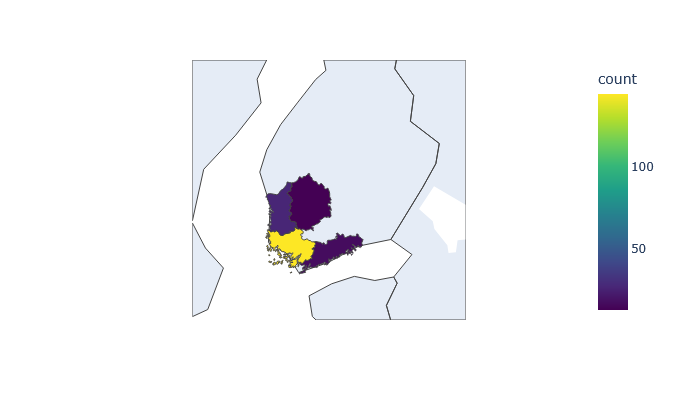

In [21]:
fig = px.choropleth(t_r_df, geojson=test_finnish_regions, locations='id', color='count',
                           color_continuous_scale="Viridis",scope='europe', width=800, height = 400
                          )
fig

In [22]:
name_to_band_id['Sentenced']

['3540398641', '162']

In [23]:
for i in range(len(nu_test_groups)):
    if '162' in nu_test_groups[i]:
        print(i)

1


In [50]:
"Metallica" in [band_id_to_name[i][2] for i in communities_generator[1]]

False

In [78]:
sought_band = 'Aarni'

for community_dex in range(len(communities_generator)): 
    community = communities_generator[community_dex]
    com_band_info = [band_id_to_name[i][2] for i in community]
    com_band_names = [i[0] for i in com_band_info] 
    if sought_band in com_band_names: 
        print(community_dex)

7


In [63]:
'Victim of Pain' in ['Victim of Pain', 'United States', 'Thrash Metal', 'Split-up']

True

In [64]:
com_band_names

['Below', 'Teaser Sweet', 'Firebug', 'Hellfueled']

0
[(0, 1706)]
0
{'black': 0.06, 'death': 0.15, 'doom': 0.05, 'electronic': 0.01, 'experimental': 0.0, 'folk': 0.01, 'gothic': 0.02, 'grindcore': 0.01, 'groove': 0.04, 'heavy': 0.23, 'core': 0.05, 'power': 0.1, 'progressive': 0.09, 'speed': 0.02, 'symphonic': 0.02, 'thrash': 0.15}


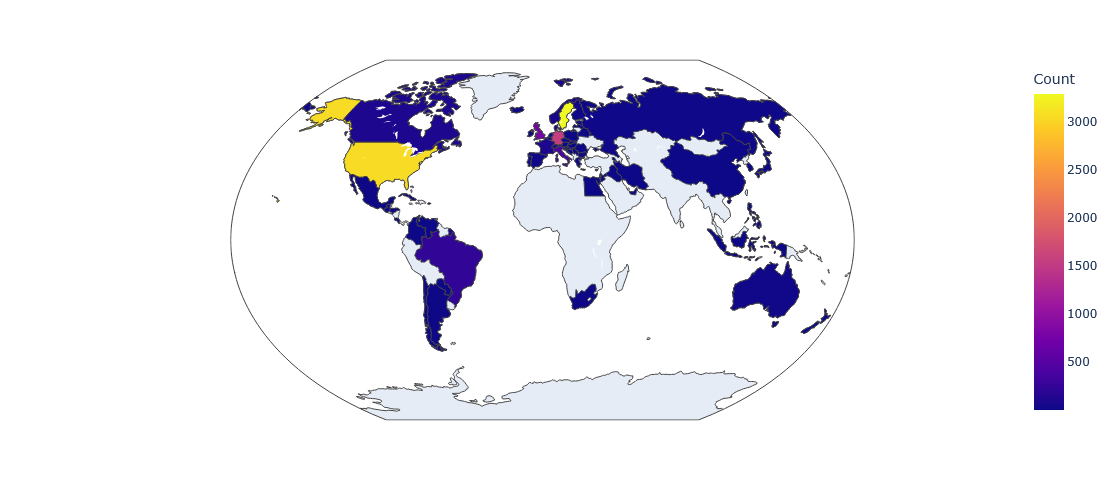

In [129]:
sought_band = 'Black Sabbath'
sought_bands = []


for community_dex in range(len(communities_generator)): 
    
    community = communities_generator[community_dex]
    com_band_info = [band_id_to_name[i][2] for i in community]
    com_band_names = [i[0] for i in com_band_info] 
    if sought_band in com_band_names: 
        print(community_dex)
        sought_bands.append((community_dex, list(com_band_names).index(sought_band)))
if len(sought_bands) == 1: 
    community_number = sought_bands[0][0]
# else: 
#     print(f"There are {len(sought_bands)} bands called {sought_band}")
#     print("Did you mean: ")
#     for band_dex in range(len(sought_bands)):
#         band = sought_bands[band_dex]
#         print(f"{band_dex}. The {sought_band} with {list(communities_generator[band[0]])[band[1]]}")
    


print(sought_bands)

international_classics = communities_generator[community_number] 
international_classics = tally_countries(international_classics)
international_classics = [(i, international_classics[i]) for i in international_classics.keys()]
international_classics = sorted(international_classics, key = lambda x: -x[1])

df = pd.DataFrame(international_classics, columns = ['Country','Count'])
df['logcount'] = np.log(df['Count'])
#tally_countries(communities_generator[7])

print(community_number)
print(tally_genres(communities_generator[community_number], band_info, True))


px.choropleth(data_frame=df,locations='Country',locationmode='country names',color='Count',
             projection='kavrayskiy7', width = 1000, height=500)




In [124]:
list(communities_generator[band[0]])band[1]

SyntaxError: invalid syntax (3338855302.py, line 1)

In [125]:
band[1]

428